# extra Dependencies

- BopFox Featurizer
- Tools in this folder

In [9]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

In [10]:
AtomsObjects  = pd.read_pickle('Cr-Co-W/Atomsobjects/CrCoW-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [21]:
AtomsObjects

,atoms,file
index,,
Cr_pv10Co_pv14.C36-BABBA.FM,"(Atom('Cr', [2.250772119913588, 1.299483309421...",[Cr-Co-W/data/Cr_pv-Co_pv/POSCAR-initial/C36-B...
Co_pv14W_sv16.sigma-AABBA.FM,"(Atom('Co', [0.0, 0.0, 0.0], index=0), Atom('C...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/sigma-...
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,"(Atom('Cr', [0.0, 0.0, 1.36622002472524], inde...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,"(Atom('Cr', [2.2438740225594285, 1.29550069283...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,"(Atom('Cr', [0.0, 0.0, 1.3747513662520061], in...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,"(Atom('Cr', [0.0, 0.0, 0.0], index=0), Atom('C...",[Cr-Co-W/data/Cr_pv-Co_pv/POSCAR-initial/chi-A...
Cr_pv2W_sv11.mu-BBABB.FM,"(Atom('Cr', [0.0, 0.0, 4.018916397121533], ind...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/mu-BBA...
Cr_pv20Co_pv4.C36-BAAAA.FM,"(Atom('Cr', [2.284644693168177, 1.319039639981...",[Cr-Co-W/data/Cr_pv-Co_pv/POSCAR-initial/C36-B...


In [12]:
AtomsObjects.atoms[0]

Atoms(symbols='Cr10Co14', pbc=True, cell=[[2.250772119913588, -3.89844985029633, 0.0], [2.250772119913588, 3.89844985029633, 0.0], [0.0, 0.0, 14.771421287099772]])

In [13]:
from ase.visualize.plot import plot_atoms

<AxesSubplot:>

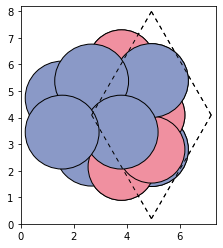

In [14]:

plot_atoms(AtomsObjects.atoms[0])

# Compute BOP features 

just chek that 
- The bopfox binary is compiled correcty
- if you need to load intel modules , do it before starting the notebook.

__Parameters__

`dataset`
makes reference to the path where results will be stored

`components` is a string to attach to filenames.

`input pickle` perhaps you have partial results, then you can use it. If `retry=True` all the samples will be calculated again. Otherwise, only the samples without bop results will be calculated.

`cutoff:str = "table"` works best, but I am not sure how your case works. You probably need to set it by hand.: `cutoff: float`.


__Output__

a pd dataframe with bop paramaters, the mapping to the atoms objects is in the index. The elements of the values in the df are np.ndarray:

```
M = M[atom_index,recursion_order]
```


In [15]:
dataset = 'Cr-Co-W'#
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os', 'projections_sos']
cutoff = 'table'
atoms = 'initial'
moments = 16
retry = True

In [16]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'parallel_{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
    if retry:
        BOPC = BopfoxFeatures(
                AtomsObjects['atoms'],modelsfile, modelname=model,
                cutoffby=cutoff, 
                binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
                moments = moments
                )
        BOPC.calculate_bop_forall(ForceKeepSpecies=True,
                input_pickle = resultspickle[model]
                )
        results[model] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) #
        results[model].to_pickle(resultspickle[model])
    else:
        results[model] = pd.read_pickle(resultspickle[model]) #

atoms:  initial model:  canonical   cutoff:  table  moments: 16


  0%|          | 0/1688 [00:00<?, ?it/s] 

atoms:  initial model:  projections   cutoff:  table  moments: 16


  0%|          | 0/1688 [00:00<?, ?it/s] 

atoms:  initial model:  projections_os   cutoff:  table  moments: 16


  0%|          | 0/1688 [00:00<?, ?it/s] 

return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
atoms:  initial model:  projections_sos   cutoff:  table  moments: 16


  0%|          | 0/1688 [00:00<?, ?it/s] 

__expand the bop parameters__

In [24]:
results['canonical']['normed_moments']

index
Cr_pv10Co_pv14.C36-BABBA.FM         [[0.0703407773, 0.082937218, 0.0075929867, 0.0...
Co_pv14W_sv16.sigma-AABBA.FM        [[0.0609144073, 0.2241810026, 0.0173726741, 0....
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM     [[0.0814751297, 0.077278343, 0.0097522327, 0.0...
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM     [[0.0703407773, 0.082937218, 0.0075929867, 0.0...
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM     [[0.0814751297, 0.077278343, 0.0097522327, 0.0...
                                                          ...                        
Cr_pv13Co_pv16.chi-ABAB.FM          [[0.0845189587, 0.1662151375, 0.0140483303, 0....
Cr_pv2W_sv11.mu-BBABB.FM            [[0.0809294072, 0.0833433102, 0.0129550476, 0....
Cr_pv20Co_pv4.C36-BAAAA.FM          [[0.0703407773, 0.082937218, 0.0075929867, 0.0...
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM    [[0.0703407773, 0.082937218, 0.0075929867, 0.0...
Co_pv10W_sv20.sigma-ABBBA.FM        [[0.0609144073, 0.2241810026, 0.0173726741, 0....
Name: normed_moments, Length: 1688, dtype: objec